# ResNet Training Strategy 3: Curriculum Learning (Prediction Difficulty)

CIFAR-10: 60,000 32x32 colour images in 10 classes
- 50,000 training images | 10,000 test images
- Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

**Strategy**: Curriculum Learning based on prediction difficulty.

1. Train a scorer ResNet briefly on the full dataset to estimate sample difficulty.
2. Rank training samples by per-sample loss from easy to hard.
3. Train the final ResNet in stages, starting with the easiest samples and gradually introducing harder ones:
   - Stage 1: Easiest 20% (5 epochs)
   - Stage 2: Easiest 40% (5 epochs)
   - Stage 3: Easiest 60% (5 epochs)
   - Stage 4: Easiest 80% (5 epochs)
   - Stage 5: All 100% (5 epochs)

Total: 25 epochs — matched to the progressive baseline.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
tf.__version__

'2.19.0'

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow(x_test, y_test, batch_size=64)

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

## Part 2 - Building the ResNet

We train the scorer and final model with the same ResNet50 backbone and a small custom classification head.

In [7]:
def build_resnet():
    base_model = applications.ResNet50(
        include_top=False,
        weights=None,
        input_shape=(32, 32, 3)
    )

    resnet_model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    return resnet_model

## Part 3 - Scoring Samples by Difficulty

A lightly trained scorer model estimates per-sample loss so the training data can be ordered from easy to hard.

In [8]:
print("Building scorer model to assess sample difficulty...")
scorer = build_resnet()
scorer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

scorer_train_set = train_datagen.flow(x_train, y_train, batch_size=64)
scorer.fit(x=scorer_train_set, epochs=3, verbose=1)

print("\nScorer training complete.")

Building scorer model to assess sample difficulty...
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 122s 82ms/step - accuracy: 0.1743 - loss: 2.5304
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.2689 - loss: 2.0261
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.3317 - loss: 1.8533

Scorer training complete.


In [9]:
print("Computing per-sample difficulty scores...")

x_train_normalized = x_train.astype('float32') / 255.0
predictions = scorer.predict(x_train_normalized, batch_size=256, verbose=1)

per_sample_loss = np.zeros(len(x_train))
for i in range(len(x_train)):
    true_label = int(y_train[i][0])
    pred_prob = predictions[i][true_label]
    pred_prob = np.clip(pred_prob, 1e-7, 1.0)
    per_sample_loss[i] = -np.log(pred_prob)

print(f"\nDifficulty score statistics:")
print(f"  Min loss (easiest):  {per_sample_loss.min():.4f}")
print(f"  Max loss (hardest):  {per_sample_loss.max():.4f}")
print(f"  Mean loss:           {per_sample_loss.mean():.4f}")
print(f"  Median loss:         {np.median(per_sample_loss):.4f}")

Computing per-sample difficulty scores...
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step

Difficulty score statistics:
  Min loss (easiest):  0.0713
  Max loss (hardest):  8.5729
  Mean loss:           1.7007
  Median loss:         1.6008


In [10]:
difficulty_order = np.argsort(per_sample_loss)

x_train_sorted = x_train[difficulty_order]
y_train_sorted = y_train[difficulty_order]
loss_sorted = per_sample_loss[difficulty_order]

print("Training data sorted by difficulty (easy → hard).")
print(f"  Easiest 5 losses: {loss_sorted[:5]}")
print(f"  Hardest 5 losses: {loss_sorted[-5:]}")

Training data sorted by difficulty (easy → hard).
  Easiest 5 losses: [0.07132176 0.0730477  0.07382868 0.0772916  0.08112345]
  Hardest 5 losses: [7.2878418  7.38146257 7.74204206 7.85210419 8.57292938]


### Visualize the difficulty distribution

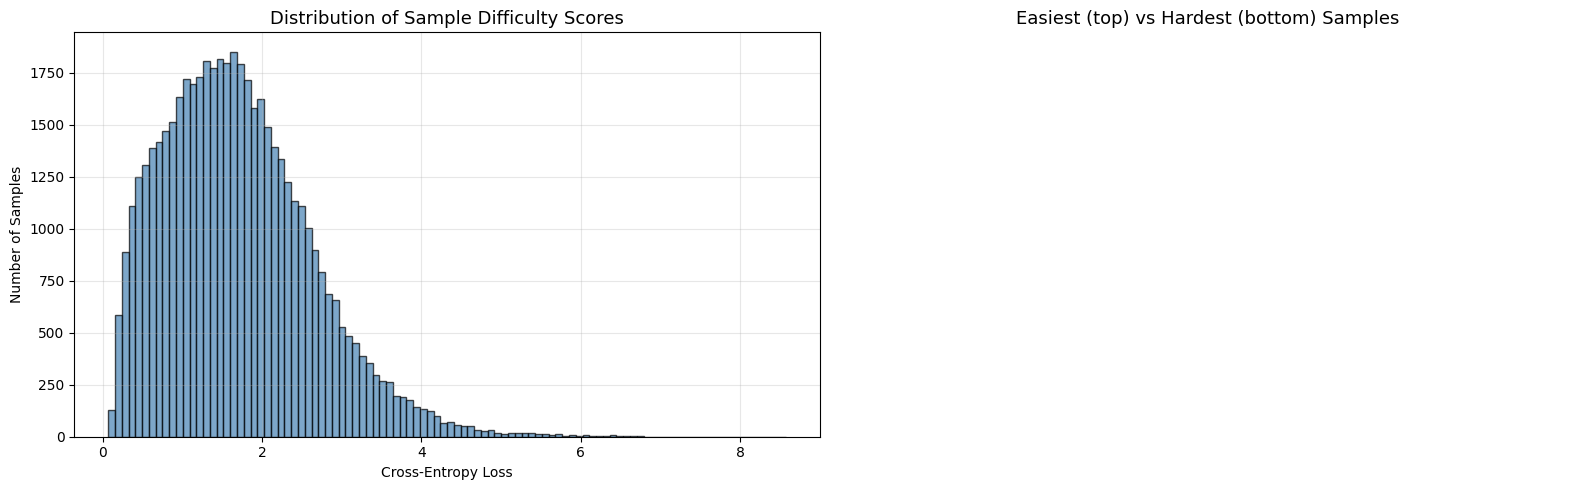

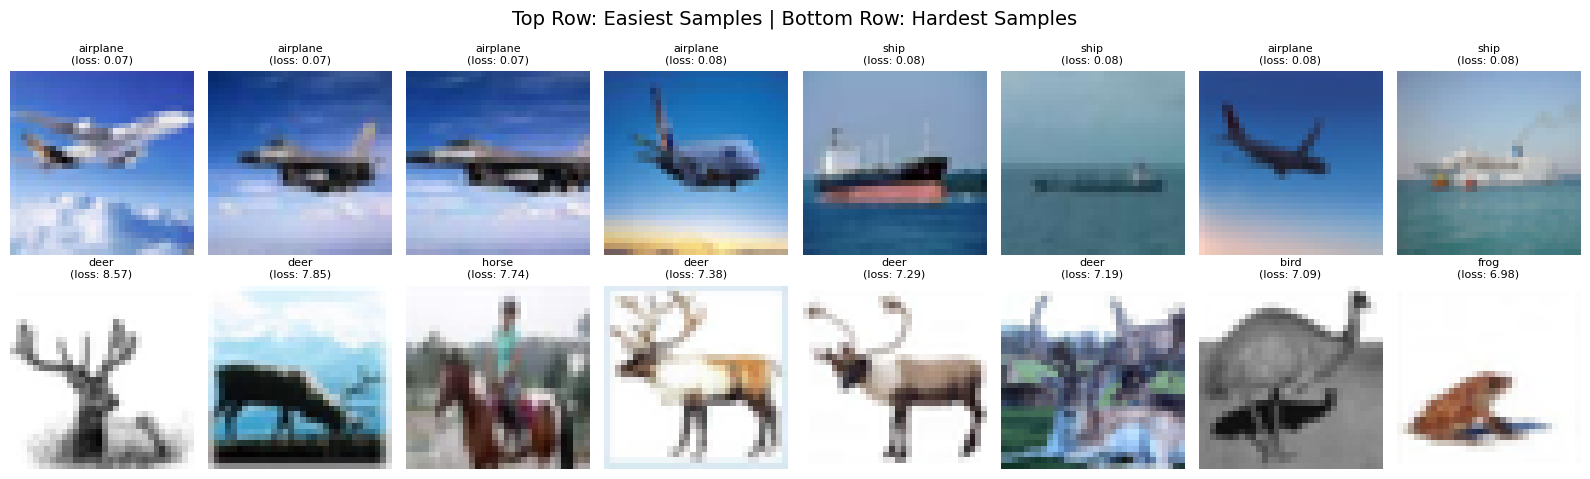

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_sample_loss, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Sample Difficulty Scores', fontsize=13)
axes[0].set_xlabel('Cross-Entropy Loss')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Easiest (top) vs Hardest (bottom) Samples', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Top Row: Easiest Samples | Bottom Row: Hardest Samples', fontsize=14)

for i in range(8):
    axes[0, i].imshow(x_train_sorted[i])
    true_label = int(y_train_sorted[i][0])
    axes[0, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[i]:.2f})', fontsize=8)
    axes[0, i].axis('off')

    idx = -(i + 1)
    axes[1, i].imshow(x_train_sorted[idx])
    true_label = int(y_train_sorted[idx][0])
    axes[1, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[idx]:.2f})', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Part 4 - Curriculum Training

Now we train a fresh model using the curriculum (easy → hard) ordering.

In [12]:
curriculum_fractions = [0.20, 0.40, 0.60, 0.80, 1.00]
epochs_per_stage = 5

print("Curriculum Learning Schedule (Easy → Hard):")
print("=" * 60)
for i, frac in enumerate(curriculum_fractions):
    n_samples = int(len(x_train_sorted) * frac)
    start_loss = loss_sorted[0]
    end_loss = loss_sorted[n_samples - 1]
    print(f"Stage {i + 1}: Easiest {frac*100:.0f}% → {n_samples:,} samples "
          f"(loss range: {start_loss:.3f} - {end_loss:.3f}) ({epochs_per_stage} epochs)")
print(f"\nTotal epochs: {len(curriculum_fractions) * epochs_per_stage}")

Curriculum Learning Schedule (Easy → Hard):
Stage 1: Easiest 20% → 10,000 samples (loss range: 0.071 - 0.862) (5 epochs)
Stage 2: Easiest 40% → 20,000 samples (loss range: 0.071 - 1.364) (5 epochs)
Stage 3: Easiest 60% → 30,000 samples (loss range: 0.071 - 1.839) (5 epochs)
Stage 4: Easiest 80% → 40,000 samples (loss range: 0.071 - 2.440) (5 epochs)
Stage 5: Easiest 100% → 50,000 samples (loss range: 0.071 - 8.573) (5 epochs)

Total epochs: 25


In [13]:
resnet_model = build_resnet()
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,018 (92.02 MB)

 Trainable params: 24,065,802 (91.80 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [14]:
full_history = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

stage_boundaries = []

for stage_idx, fraction in enumerate(curriculum_fractions):
    n_samples = int(len(x_train_sorted) * fraction)
    x_subset = x_train_sorted[:n_samples]
    y_subset = y_train_sorted[:n_samples]
    training_set = train_datagen.flow(x_subset, y_subset, batch_size=64)

    start_loss = loss_sorted[0]
    end_loss = loss_sorted[n_samples - 1]

    print(f"\n{'='*70}")
    print(f"STAGE {stage_idx + 1}/{len(curriculum_fractions)}: Training with easiest {fraction*100:.0f}% ({n_samples:,} samples)")
    print(f"Loss range: {start_loss:.3f} - {end_loss:.3f}")
    print(f"{'='*70}")

    stage_boundaries.append(len(full_history['accuracy']))

    history = resnet_model.fit(
        x=training_set,
        validation_data=test_set,
        epochs=epochs_per_stage
    )

    for key in full_history:
        full_history[key].extend(history.history[key])

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"\nStage {stage_idx + 1} Complete:")
    print(f"  Train Accuracy: {final_train_acc:.4f}")
    print(f"  Val Accuracy:   {final_val_acc:.4f}")

print(f"\n{'='*70}")
print("Curriculum learning complete!")
print(f"{'='*70}")


STAGE 1/5: Training with easiest 20% (10,000 samples)
Loss range: 0.071 - 0.862
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 89s 237ms/step - accuracy: 0.3622 - loss: 2.1847 - val_accuracy: 0.1000 - val_loss: 2.7426
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.5456 - loss: 1.4075 - val_accuracy: 0.1275 - val_loss: 2.8602
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.6246 - loss: 1.1499 - val_accuracy: 0.2091 - val_loss: 3.0317
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.6751 - loss: 0.9696 - val_accuracy: 0.3051 - val_loss: 2.7518
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7140 - loss: 0.8350 - val_accuracy: 0.2903 - val_loss: 3.6964

Stage 1 Complete:
  Train Accuracy: 0.7140
  Val Accuracy:   0.2903

STAGE 2/5: Training with easiest 40% (20,000 samples)
Loss range: 0.071 - 1.364
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.5635 - loss: 1.2514 - val_accuracy: 0.3362 - val_loss: 2

## Part 5 - Evaluating the Results

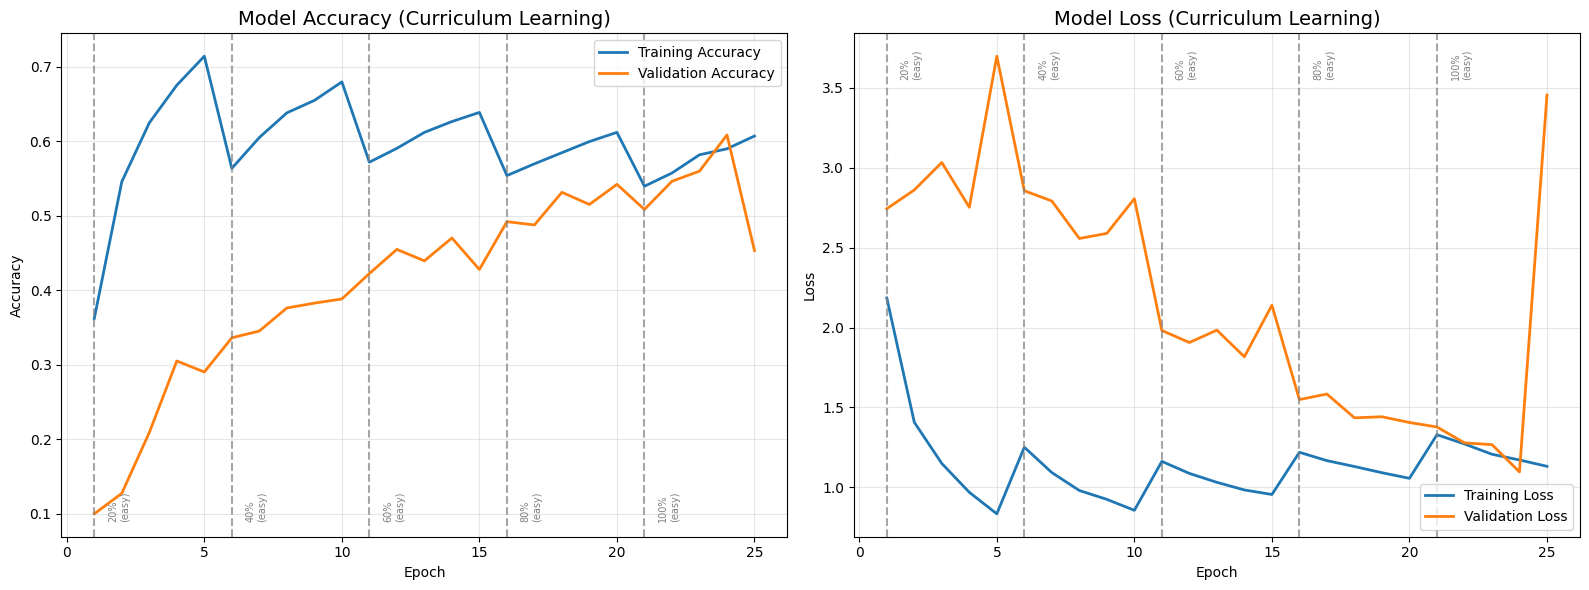

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(full_history['accuracy']) + 1)

ax1.plot(epochs_range, full_history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(epochs_range, full_history['val_accuracy'], label='Validation Accuracy', linewidth=2)
for i, boundary in enumerate(stage_boundaries):
    frac = curriculum_fractions[i]
    ax1.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax1.text(boundary + 1.5, ax1.get_ylim()[0] + 0.02, f'{frac*100:.0f}%\n(easy)',
             fontsize=7, color='gray', rotation=90, va='bottom')

ax1.set_title('Model Accuracy (Curriculum Learning)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, full_history['loss'], label='Training Loss', linewidth=2)
ax2.plot(epochs_range, full_history['val_loss'], label='Validation Loss', linewidth=2)
for i, boundary in enumerate(stage_boundaries):
    frac = curriculum_fractions[i]
    ax2.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax2.text(boundary + 1.5, ax2.get_ylim()[1] - 0.1, f'{frac*100:.0f}%\n(easy)',
             fontsize=7, color='gray', rotation=90, va='top')

ax2.set_title('Model Loss (Curriculum Learning)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
test_loss, test_accuracy = resnet_model.evaluate(test_set, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4533 - loss: 3.4538

Test Loss     : 3.4538
Test Accuracy : 0.4533


In [17]:
resnet_model.save('cifar10_resnet_curriculum_model.keras')

## Part 6 - Making a single prediction

In [22]:
idx = np.random.randint(0, len(x_test))
test_image = x_test[idx]

test_image_input = test_image.astype('float32') / 255.0
test_image_input = np.expand_dims(test_image_input, axis=0)

result = resnet_model.predict(test_image_input)
predicted_class = np.argmax(result[0])
confidence = result[0][predicted_class] * 100
actual_class = int(y_test[idx][0])

print(f"Predicted class : {class_names[predicted_class]} ({confidence:.1f}% confidence)")
print(f"Actual class    : {class_names[actual_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted class : truck (61.1% confidence)
Actual class    : automobile


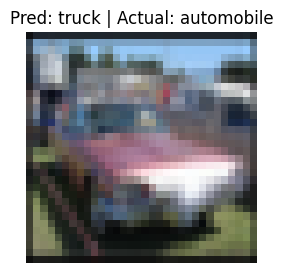

In [23]:
plt.figure(figsize=(3, 3))
plt.imshow(test_image)
plt.title(f"Pred: {class_names[predicted_class]} | Actual: {class_names[actual_class]}")
plt.axis('off')
plt.show()